In [1]:
# Disable JAXFEM logging
import jax_fem                       # forces setup_logger() to run NOW
import logging
jl = logging.getLogger('jax_fem')
jl.setLevel(logging.WARNING)         # or logging.ERROR to also silence INFO
jl.handlers.clear()                  # remove jax_fem's own StreamHandler
jl.propagate = False

import os, glob
import numpy as np
import pyvista as pv
from simsopt import load, save
from simsopt.configs import get_data
from simsopt.geo import plot, CurveLength
from simsopt.field import (
    BiotSavart, Current,
    coils_via_symmetries,
    RegularizedCoil, LpCurveForce,
)
from coil_fem.simsopt import CoilSupportDiscrete, CoilSupportTopBottom
from coil_fem.simsopt import CoilFEMObjective
from optimization import (
    load_eq, 
    run_filament_free, 
    increase_base_curve_order,
    mesh_options,
    problem_options,
    material_options_const_temp,
    material_options_variable_temp,
)

       __       ___      ___   ___                _______  _______ .___  ___. 
      |  |     /   \     \  \ /  /               |   ____||   ____||   \/   | 
      |  |    /  ^  \     \  V  /      ______    |  |__   |  |__   |  \  /  | 
.--.  |  |   /  /_\  \     >   <      |______|   |   __|  |   __|  |  |\/|  | 
|  `--'  |  /  _____  \   /  .  \                |  |     |  |____ |  |  |  | 
 \______/  /__/     \__\ /__/ \__\               |__|     |_______||__|  |__| 
                                                                              



In [2]:
eq, Bnormal_plasma, plasma_surface_vc, vc = load_eq('wout.nc')
curves, currents, axis, nfp, bs = get_data('w7x', coil_order=10, points_per_period=8)
coils_w7x = coils_via_symmetries(curves[:5], currents[:5], nfp, True)
coils_support = load('coils_support.json') # Corresponds to case (A)
coils_fixed = load('coils_fixed.json')     # Corresponds to case (B)
coils_movable = load('coils_movable.json') # Corresponds to case (C)
coils_force = load('coils_force.json')     # Corresponds to case (D)

Jstress_w7x = CoilFEMObjective(
    base_curves      = [c.curve for c in coils_w7x[:5]],
    base_currents    = [c.current for c in coils_w7x[:5]],
    base_supports    = [
        CoilSupportTopBottom(
            clamp_radius=0.3,
        ) for _ in range(5)
    ],
    metrics          = ('l2_von_mises',),
    metric_weights   = (1.,),
    nfp              = nfp,
    stellsym         = True,
    mesh_options     = mesh_options,
    material_options = material_options_const_temp,
    problem_options  = problem_options,
)
Jstress_force = CoilFEMObjective(
    base_curves      = [c.curve for c in coils_force[:5]],
    base_currents    = [c.current for c in coils_force[:5]],
    base_supports    = [
        CoilSupportTopBottom(
            clamp_radius=0.3,
        ) for _ in range(5)
    ],
    metrics          = ('l2_von_mises',),
    metric_weights   = (1.,),
    nfp              = nfp,
    stellsym         = True,
    mesh_options     = mesh_options,
    material_options = material_options_const_temp,
    problem_options  = problem_options,
)
Jstress_fixed = load('Jstress_fixed.json')[0]
Jstress_movable = load('Jstress_movable.json')[0]
Jstress_support = load('Jstress_support.json')[0]

In [3]:
from pathlib import Path

folder_path = Path('fem_data_support')
if not folder_path.is_dir():
    Jstress_w7x.save_run_vtu('fem_data_w7x', prefix='coil_')
    Jstress_fixed.save_run_vtu('fem_data_fixed', prefix='coil_')
    Jstress_force.save_run_vtu('fem_data_force', prefix='coil_')
    Jstress_movable.save_run_vtu('fem_data_movable', prefix='coil_')
    Jstress_support.save_run_vtu('fem_data_support', prefix='coil_')

solving with float64


In [4]:

# ---- edit these ----
folders = [
    'fem_data_w7x',
    'fem_data_support',
    'fem_data_fixed',
    'fem_data_movable',
    'fem_data_force',
]
names = {
    'fem_data_w7x': 'Init',
    'fem_data_support': 'Case A',
    'fem_data_fixed': 'Case B',
    'fem_data_movable': 'Case C',
    'fem_data_force': 'Case D',
}
quantities = ['von_mises_MPa']            # your 3 cell-data array names

names_quantities = {
    'von_mises_MPa': r'$\sigma_v$',
}
names_quantities = {
    'von_mises_MPa': r'$\sigma_v$',
}
# --------------------

# Load each folder's 5 vtu files once and merge them into a single object
meshes = {}
for f in folders:
    parts = [pv.read(p) for p in sorted(glob.glob(os.path.join(f, '*.vtu')))]
    meshes[f] = pv.merge(parts)        # all 5 meshes -> one combined mesh

def values(mesh, q):                   # handle scalar OR vector/tensor cell data
    a = np.asarray(mesh.cell_data[q])
    return np.linalg.norm(a, axis=1) if a.ndim == 2 and a.shape[1] > 1 else a.ravel()

# ---- camera / layout knobs ----
zoom        = 1.6     # >1 zooms in, <1 zooms out
azimuth_deg = 180     # rotate camera around the origin in the xy-plane
panel_px    = 1200     # square subplot size (pixels) -> window is (panel_px*N, panel_px)
glyph_scale = 0.02     # sphere radius [m] at support_weight == 1 (0 disables glyphs)
edge_angle  = 15      # deg; larger -> fewer edges kept (only sharper creases)
tick_interval = 200   # colorbar tick spacing (data units, e.g. MPa)
# --------------------------------

import vtk   # for custom colorbar tick labels

def surface_edges(mesh, angle):
    """Clean wireframe: boundary + feature (crease) edges of the outer surface.

    Avoids the tet-diagonal clutter you get from add_mesh(show_edges=True)."""
    return mesh.extract_surface().extract_feature_edges(
        feature_angle=angle,
        boundary_edges=True,
        feature_edges=True,
        manifold_edges=False,
        non_manifold_edges=False,
    )

def make_support_glyphs(mesh, scale):
    """Grey sphere glyphs at supported nodes, radius proportional to weight."""
    if scale <= 0 or "support_weights" not in mesh.point_data:
        return None
    w = np.asarray(mesh.point_data["support_weights"]).ravel()
    mask = w > 0.0
    if not mask.any():
        return None
    cloud = pv.PolyData(np.asarray(mesh.points)[mask])
    cloud["support_weights"] = w[mask]
    # pv.Sphere has radius 0.5, so factor=2*scale gives radius==scale at weight 1
    sphere = pv.Sphere(theta_resolution=12, phi_resolution=12)
    return cloud.glyph(scale="support_weights", geom=sphere,
                       factor=2.0 * scale, orient=False)

def rotate_camera_xy(plotter, angle_deg, center=(0.0, 0.0, 0.0)):
    '''Rotate the (shared) camera in xy about the z-axis through ``center``.'''
    th = np.radians(angle_deg)
    c, s = np.cos(th), np.sin(th)
    R = np.array([[c, -s, 0.0], [s, c, 0.0], [0.0, 0.0, 1.0]])
    ctr = np.asarray(center, dtype=float)
    cam = plotter.camera
    cam.position    = tuple(ctr + R @ (np.asarray(cam.position)    - ctr))
    cam.focal_point = tuple(ctr + R @ (np.asarray(cam.focal_point) - ctr))
    cam.up          = tuple(R @ np.asarray(cam.up))   # direction: no translation


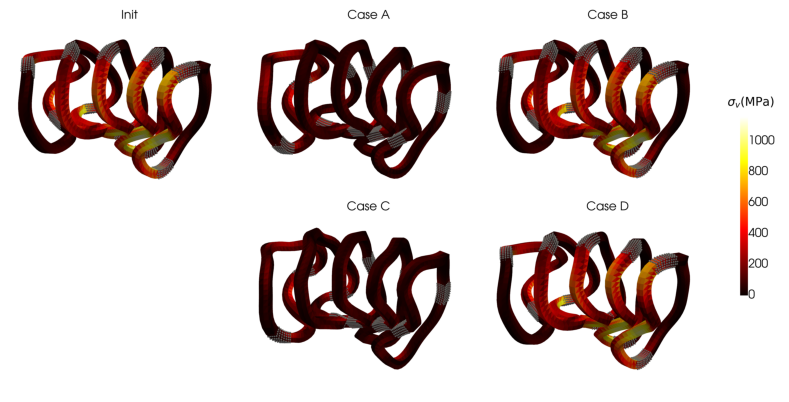

In [5]:

# Rotation center = mean of all vertices across all coils/folders
center = np.vstack([np.asarray(meshes[f].points) for f in folders]).mean(axis=0)

# One figure per quantity
for q in quantities:
    allvals = np.concatenate([values(meshes[f], q) for f in folders])
    clim = (0, float(allvals.max()))   # shared color range across panels

    # 2-row layout; bottom-left cell left empty:
    #   row 0: panels 0, 1, 2
    #   row 1:  _ ,  3, 4
    nrows, ncols = 2, 3
    positions = [(0, 0), (0, 1), (0, 2), (1, 1), (1, 2)]
    panel_h = int(panel_px * 0.8)
    # Extra narrow column (spanning both rows) holds one shared colorbar.
    cbar_col  = ncols
    cbar_frac = 0.22        # colorbar column width relative to a panel
    p = pv.Plotter(shape=(nrows, ncols + 1), off_screen=True,
                   groups=[(np.s_[:], cbar_col)],          # colorbar spans all rows
                   col_weights=[1.0] * ncols + [cbar_frac],
                   window_size=(int(panel_px * (ncols + cbar_frac)), panel_h * nrows),
                   border=False)        # no black border between subplots
    for i, f in enumerate(folders):
        p.subplot(*positions[i])
        p.add_text(names[f], font_size=25, position='upper_edge')
        actor = p.add_mesh(
            meshes[f], scalars=q, preference='cell', clim=clim,
            cmap='hot',
            show_scalar_bar=False,      # shared bar drawn separately below
        )
        bar_mapper = actor.mapper       # all panels share clim/cmap -> any mapper works
        glyphs = make_support_glyphs(meshes[f], glyph_scale)
        if glyphs is not None:
            p.add_mesh(glyphs, color="grey", show_scalar_bar=False)
    # Link/orient only the panel cameras (not the colorbar renderer).
    p.link_views()
    p.subplot(0, 0)             # make a panel active before setting the view
    p.view_isometric()         # or p.view_xy(), p.view_xz(), etc.
    rotate_camera_xy(p, azimuth_deg, center=center)
    p.camera.zoom(zoom)

    # ---- one shared colorbar, vertically centered in the right column ----
    p.subplot(0, cbar_col)
    sb = p.add_scalar_bar(
        title=r"$\sigma_v$(MPa)",
        mapper=bar_mapper,
        vertical=True,
        position_x=0.24, position_y=0.25,
        height=0.5, width=0.4,
        title_font_size=60,
        label_font_size=60,
        fmt="%.0f",
    )
    ticks = np.arange(0.0, clim[1] + 1e-9, tick_interval)   # 0, 200, 400, ...
    labels = vtk.vtkDoubleArray()
    labels.SetNumberOfValues(len(ticks))
    for k, t in enumerate(ticks):
        labels.SetValue(k, float(t))
    sb.SetUseCustomLabels(True)
    sb.SetCustomLabels(labels)
    img = p.screenshot(f'../figures/figure_{q}.png')   # also returns the rendered RGB array
    p.close()

    # ---- preview inline in the notebook ----
    import matplotlib.pyplot as plt
    ih, iw = img.shape[:2]
    fig, ax = plt.subplots(figsize=(10, 10 * ih / iw))
    ax.imshow(img)
    ax.axis('off')
    # ax.set_title(q)
    plt.show()

pv.close_all()
plt.close('all')